<center><img src="img/logo_hse.png" width="1000"></center>

<h1><center>Прикладные задачи анализа данных</center></h1>
<h2><center>Домашнее задание 1: Генеративные сети</center></h2>

# Введение

Не все же нам MNIST генерировать. Давайте посмотрим, как генеративные модели могут использоваться не только для развлечения. Поехали!

Немного вступления и мотивации, для чего мы хотим обучать модель.

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ).

MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

#### Ок, давайте зафиксируем. Какой-то крутой телескоп позволяет открыть новые виды излучения. Идем дальше.

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение.
#### По фотографиям можно определить тип частицы из космоса: фотон или протон. Знакомая формулировка задачи, не правда ли?

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Ниже пример такой фотографии.

<center><img src="img/geo.jpg" width="400"></center>

#### Итак, каждая фотография описывается набором параметров, которые за нас считает телескоп. А что там с двумя видами частиц?

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Получение каждого такого изображения - дорогое удовольствие!


<center><img src="img/gamma_p.png" width="600"></center>

Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.

#### Итак, давайте сэкономим денег для ученых и сгенерируем хороших фотографий разных частиц. Используем для этого GAN и диффузионные модели!

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [45]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("data/magic04.data", header=None)
data.columns = names
print(data.shape)
data.head()

(19020, 11)


,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научиться генерировать параметры кластеров на изображениях телескопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [46]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [47]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [48]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [49]:
# все возможные значения
np.unique(y)

array([0., 1.])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [50]:
# Кастомный стиль
custom_style = {
    'axes.facecolor': '#1E1E2F',
    'axes.edgecolor': '#FFFFFF',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#FFFFFF',
    'ytick.color': '#FFFFFF',
    'text.color': '#FFFFFF',
    'figure.facecolor': '#1E1E2F',
    'grid.color': '#4A4A6A',
    'lines.linewidth': 2,
    'lines.color': '#FF6F61',
    'patch.edgecolor': '#FFFFFF',
    'boxplot.boxprops.color': '#FF6F61',
    'boxplot.whiskerprops.color': '#FF6F61',
    'boxplot.capprops.color': '#FF6F61',
    'boxplot.medianprops.color': '#00B4D8',
    'scatter.edgecolors': '#FF6F61'
}

plt.style.use(custom_style)

In [51]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(5 * 4, 5 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.grid()
        plt.hist(X1[:, i], bins=bins, alpha=0.3, label=label1, color="C4")
        plt.hist(X2[:, i], bins=bins, alpha=0.3, label=label2, color="C0")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

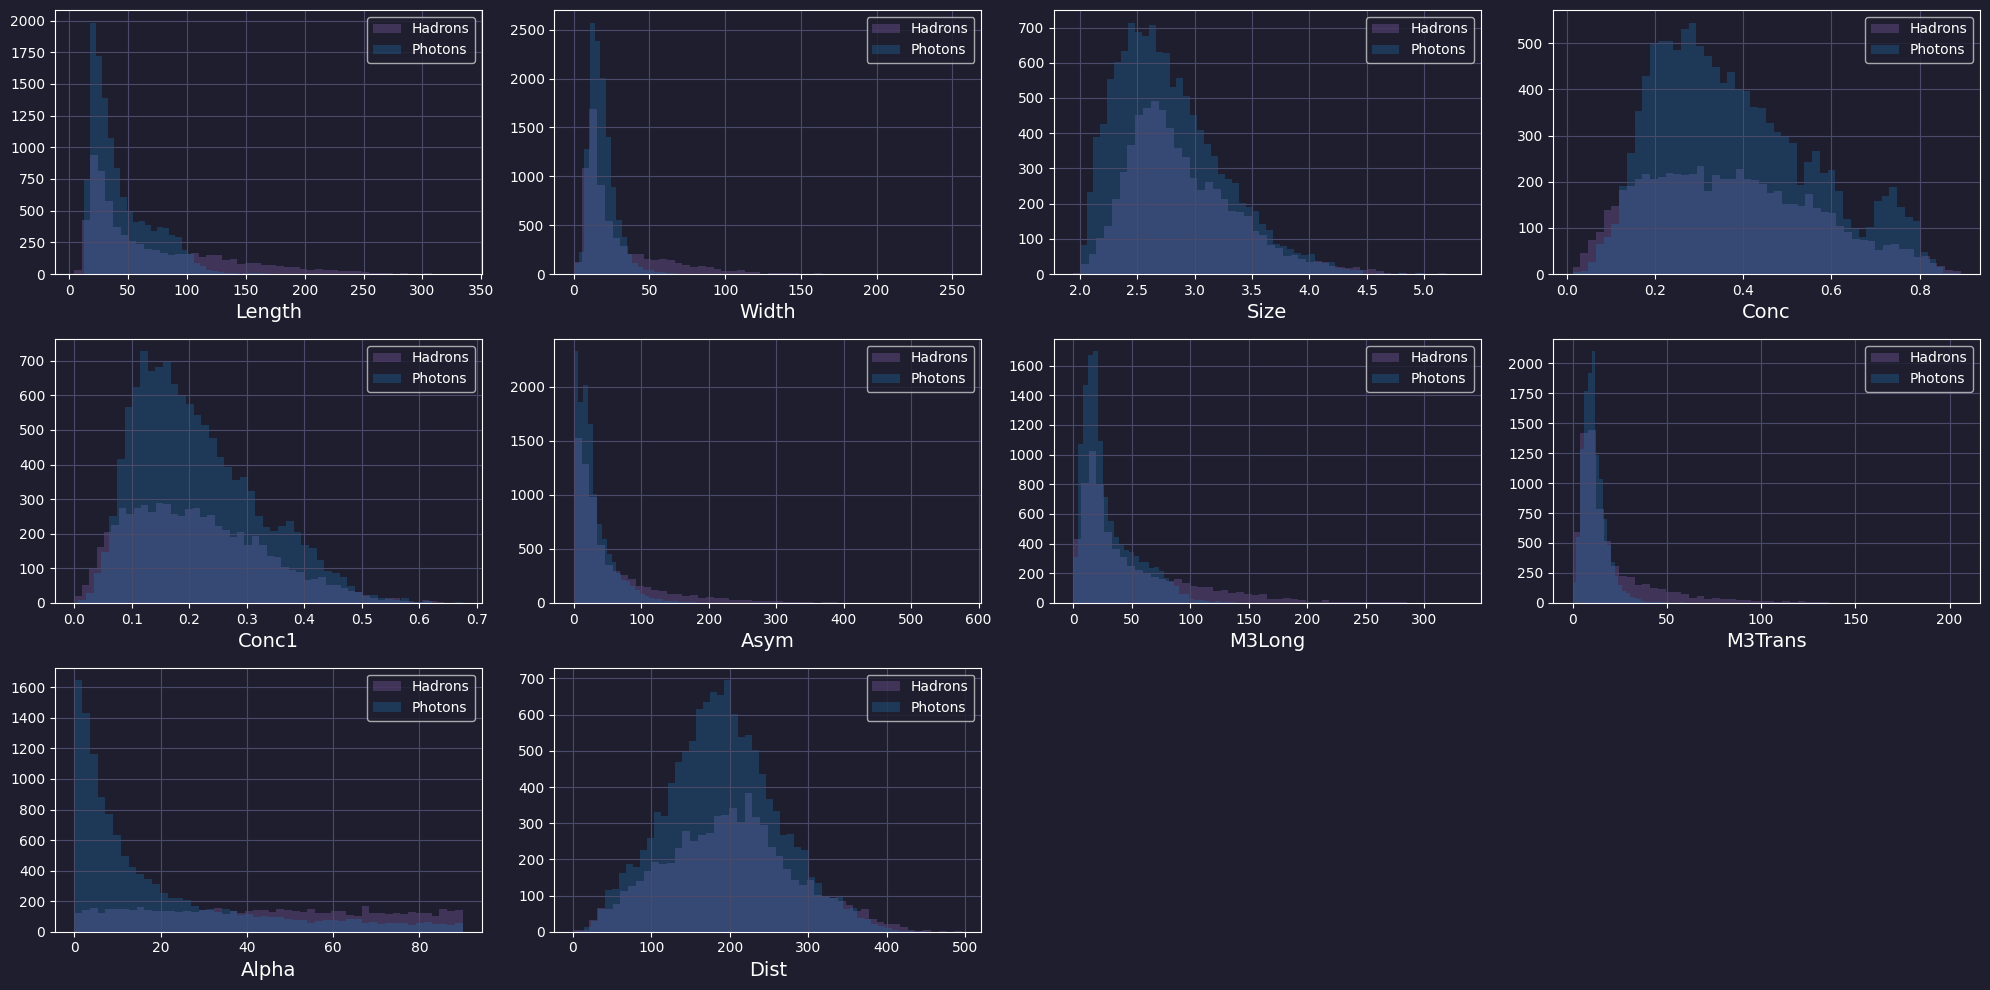

In [52]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты.

# Обучающая и тестовая выборки

In [53]:
from sklearn.model_selection import train_test_split

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)

## Задание 1 (0.2 балла)

Проиллюстрируйте распределение целевой переменной внутри train и test выборки. Совпадает ли оно? Есть ли идеи почему так?

__Подсказка__: посмотрите на клеточку с разделением данных

In [54]:
train_counts = np.unique(y_train, return_counts=True)[1]
test_counts = np.unique(y_test, return_counts=True)[1]

In [55]:
print("Train proportions:", train_counts / len(y_train))
print("Test proportions:", test_counts / len(y_test))

Train proportions: [0.35162986 0.64837014]
Test proportions: [0.35162986 0.64837014]


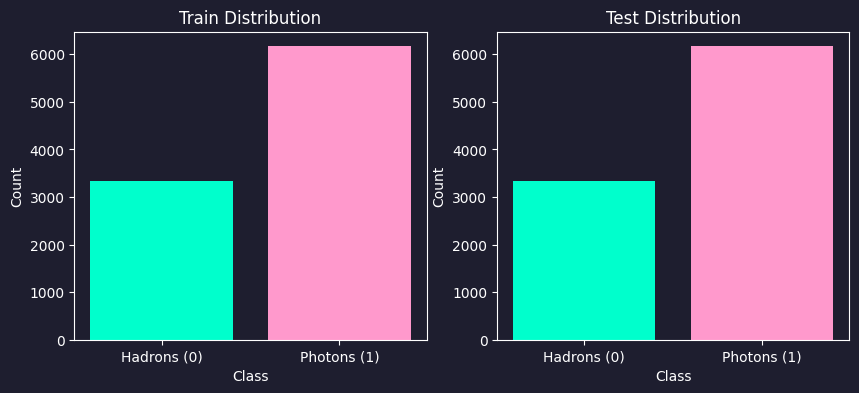

In [56]:
plt.figure(figsize=(10, 4))

# Train
plt.subplot(1, 2, 1)
bars_train = plt.bar(['Hadrons (0)', 'Photons (1)'], train_counts, color=['#00ffcc', '#ff99cc'], linewidth=1.5)
plt.title('Train Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Test
plt.subplot(1, 2, 2)
bars_train = plt.bar(['Hadrons (0)', 'Photons (1)'], test_counts, color=['#00ffcc', '#ff99cc'], linewidth=1.5)
plt.title('Test Distribution')
plt.xlabel('Class')
plt.ylabel('Count');

**Вывод**: Распределения совпадают. Причина: параметр stratify=y, который гарантирует, что данные будут разделены так, что пропорции классов будут одинаковыми между трейном и тестом.

## Задание 2 (0.8 балл)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X_train` и `X_test`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по [ссылке](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html). Используйте значение параметра `output_distribution='normal'`.

In [57]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', random_state=42)

X_train = qt.fit_transform(X_train)
X_test = qt.transform(X_test)

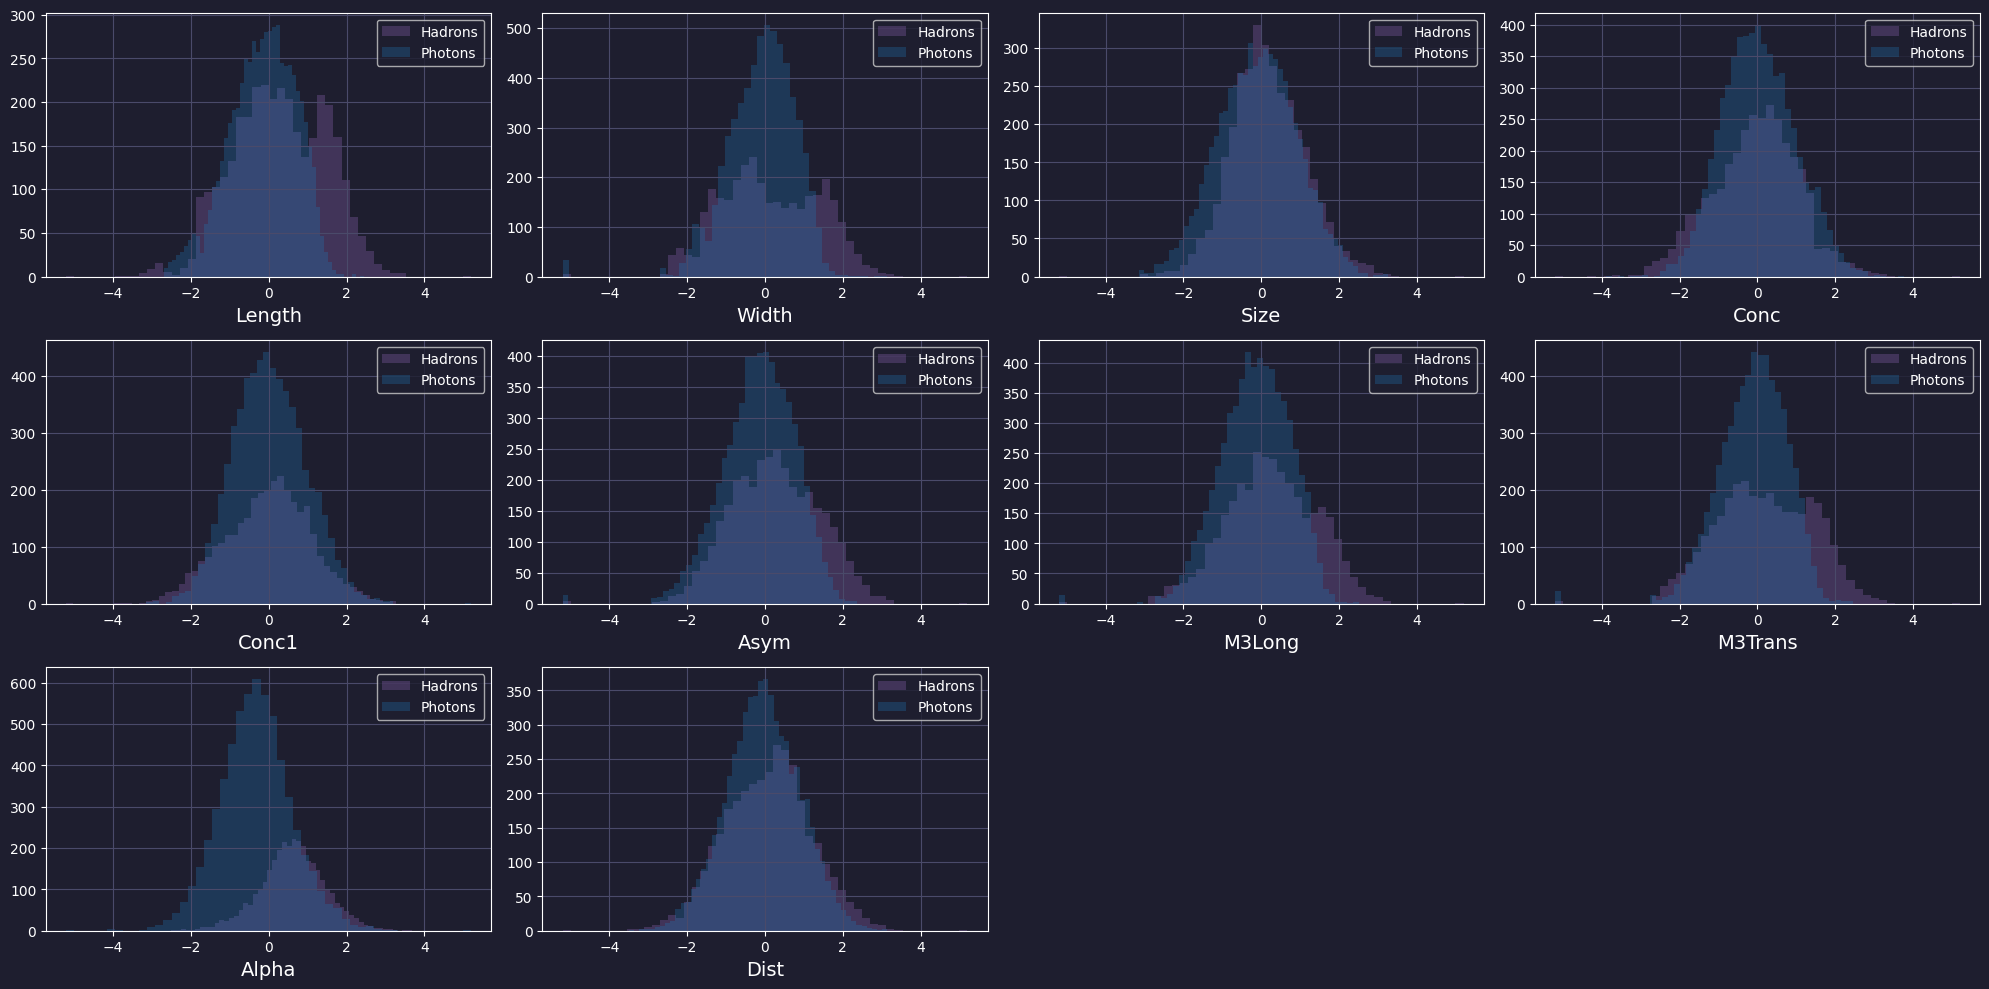

In [58]:
plot_hists(
    X_train[y_train[:, 0] == 0],
    X_train[y_train[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

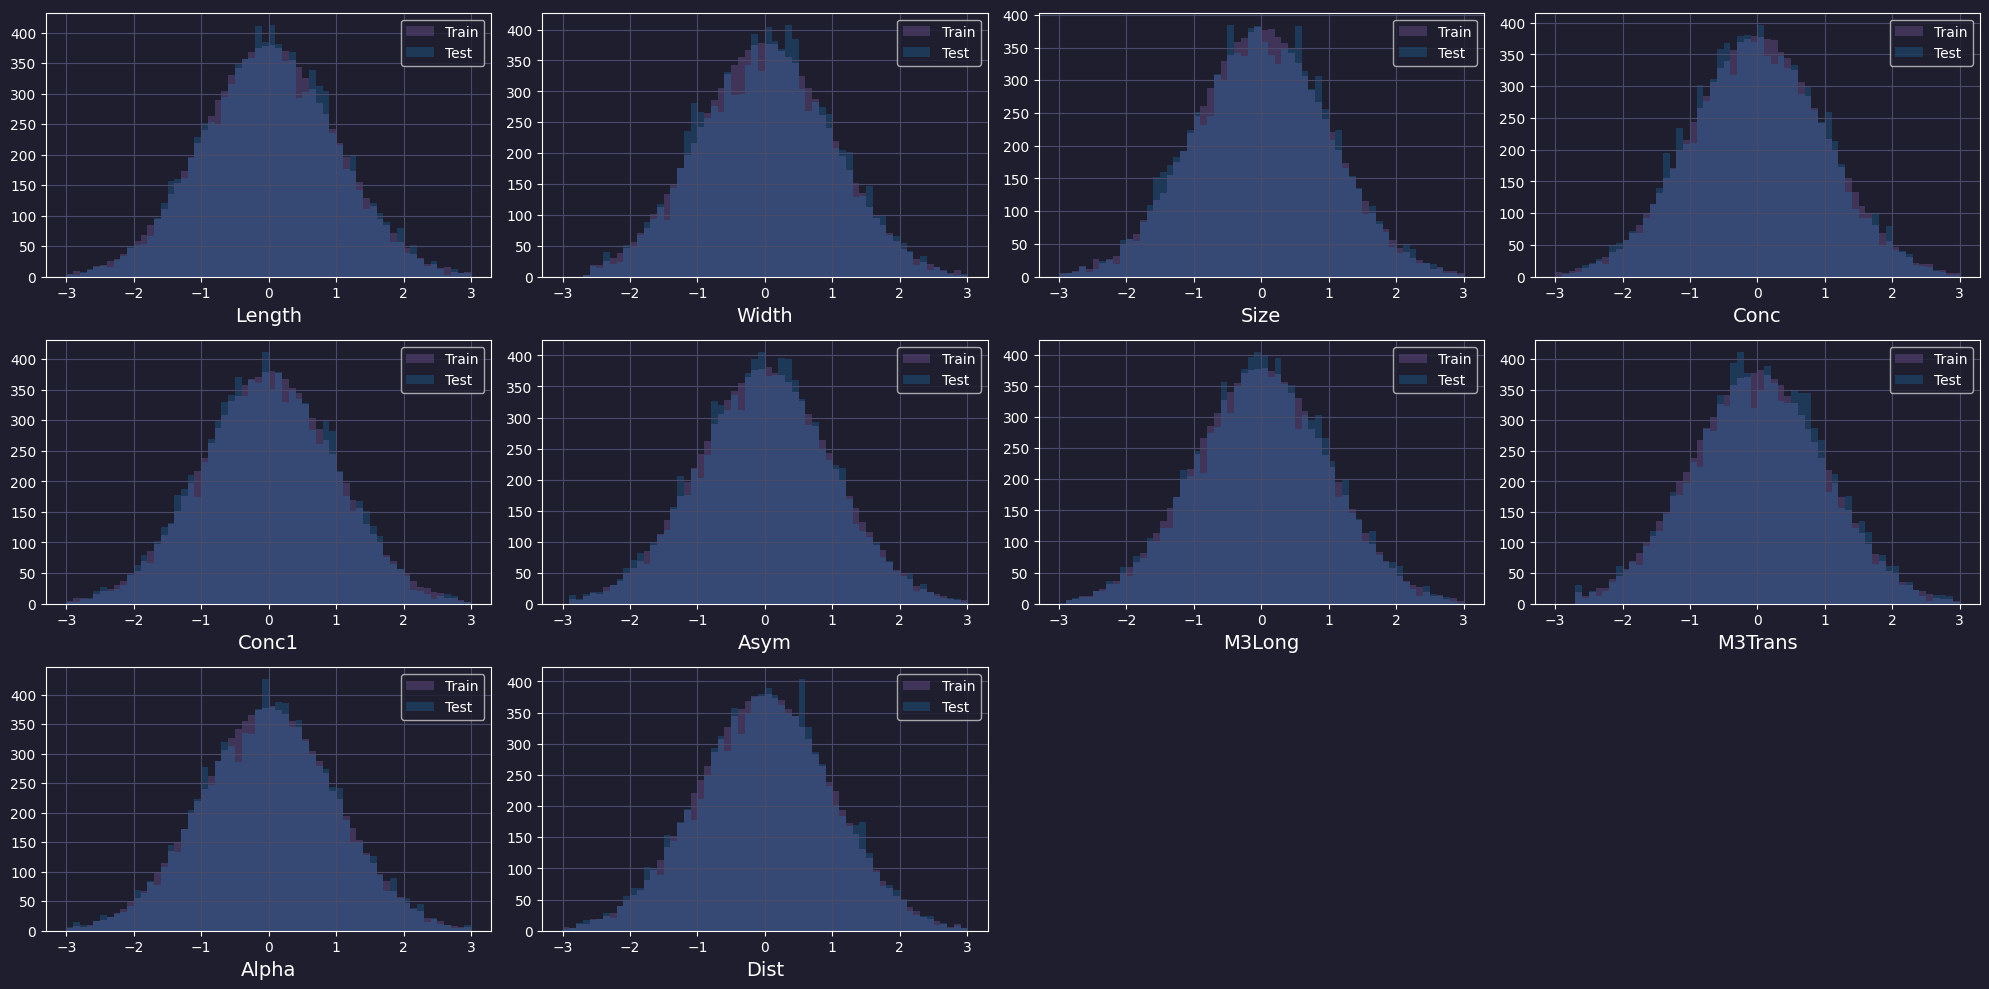

In [59]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

# Conditional WGAN

Мы будем использовать `Conditional WGAN`, который изображен на рисунке. В качестве условия `y` мы будем использовать метку класса: **0** - адрон, **1** - фотон. Таким образом, мы будем сообщать генератору для какой частицы нужно генерировать параметры изображения.

<center><img src="img/cgan.png" width="800"></center>

Генератор $\hat{x} = G(z, y)$ будет принимать на вход шумовой вектор $z$ и вектор условий $y$, а выдавать будет сгенерированный (фейковый) вектор параметров $\hat{x}$.

Дискриминатор $D(x, y)$ будет принимать на вход вектор параметров $x$ и вектор условий $y$, а возвращать будет рациональное число.

Обучать `Conditional WGAN` будем с такой функцией потерь:

$$L(G, D) = -\frac{1}{n} \sum_{x_i \in X, y_i \in y} D(x_i, y_i) + \frac{1}{n} \sum_{z_i \in Z, y_i \in y} D(G(z_i, y_i), y_i) \to \max_G \min_D$$

In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [61]:
DEVICE

device(type='cuda')

## Задание 3 (0.75 балла)

Реализуйте нейронную сеть для генератора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [63]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(Generator, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )

    def forward(self, z, y):
        zy = torch.cat((z.cuda(), y.cuda()), dim=1)
        return self.layers(zy)

## Задание 4 (0.5 балл)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [64]:
def generate(generator, y, latent_dim):
    z = torch.randn(len(y), latent_dim, device=DEVICE)
    y_tensor = torch.tensor(y, dtype=torch.float, device=DEVICE)
    with torch.no_grad():
        X_fake = generator(z, y_tensor).cpu().numpy()
    return X_fake

## Задание 5 (0.75 балла)

Реализуйте нейронную сеть для дискриминатора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Какая функция активации должна быть в конце работы модели и почему? А она вообще тут должна быть? Обоснуйте свой выбор.

In [65]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super(Discriminator, self).__init__()
        self.fully_con1 = nn.Linear(n_inputs, 100)
        self.fully_con2 = nn.Linear(100, 100)
        self.fully_con3 = nn.Linear(100, 1)
        self.sig = nn.Sigmoid()

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        output = F.relu(self.fully_con1(xy))
        output = F.relu(self.fully_con2(output))
        return self.sig(self.fully_con3(output))

**Ответ:** В конце используем сигмоиду для перевода ответов модели на отрезок от 0 до 1, чтобы получать своего рода "вероятности" классов (в случае откалиброванности модели)

## Задание 6 (0.5 балла)

Реализуйте функцию, которая принимала бы на вход набор сгенерированных и настоящих объектов, разбивала на train и test с учетом баланса классов (real и fake объектов), с соотношением 3 к 1, обучала модель логистической регрессии и градиентного бустинга, которые учились бы отличать настоящие объекты от фальшивых, после чего выводила бы accuracy score на отложенной выборке у обоих моделей.

Ответьте на вопрос: какое значение accuracy score нас бы удовлетворило больше всего? Почему?

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

def other_agent_score(X_real, y_real, X_fake, y_fake):
    X = np.concatenate((X_real, X_fake), axis=0)
    y = np.concatenate((y_real, y_fake), axis=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

    lr = LogisticRegression().fit(X_train, y_train)
    gb = GradientBoostingClassifier().fit(X_train, y_train)

    lin_reg_score = lr.score(X_test, y_test)
    boosting_score = gb.score(X_test, y_test)

    print("Linear regression score: " + str(lin_reg_score))
    print("Boosting score: " + str(boosting_score))


In [102]:
print(f'Доля наибольшого класса: {np.max(np.unique(y_train.flatten(), return_counts=True)[1])/len(y_train.flatten())}')

Доля наибольшого класса: 0.6483701366982124


**Ответ**: Accuracy на уроне случайного классификатора - то есть где-то на уровне 0.64. Если значение меньше, то предсказания модели всегда можно брать с другим знаком (ну либо в нашем случае вычитать из единицы) и получать противоположенный ответ и бОльший скор, а случайный классификатор улучшить не выйдет. Наша задача - чтобы модель не могла отличить реальные и фейковые объекты. Если модель показывает хороший скор (больше 0.64) значит она их отличает, но если она показывает плохой скор (менее 0.64) - это все еще означает, что она может их отличить (просто теперь по ее мнению фейковые объекты больше похожи на реальные, что тоже не очень хорошо, наша цель - чтобы их нельзя было отличить). Итог: скор на уровне 0.64 (доля набольшого класса и скор случайного классификатора).

## Задание 7 (1.5 балла)

Реализуйте класс для обучения генеративной модели.

- Уточнение 1: Нужно ограничивать веса дискриминатора. Для этого используйте `p.data.clamp_(-0.01, 0.01)`, где `p` веса дискриминатора. Зачем это делать можно посмотреть в оригинальной статье <https://arxiv.org/pdf/1701.07875.pdf>.
- Подсказка 1: `n_critic` - число итераций обучения дискриминатора на одну итерацию обучения генератора.
- Подсказка 2: Используйте `X_tensor = torch.tensor(X_numpy, dtype=torch.float, device=DEVICE)` для перевода numpy в тензор.

In [67]:
from tqdm import tqdm

In [68]:
class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in tqdm(range(self.n_epochs)):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                CRITIC_CYCLES = self.n_critic + 1
                current_step = i % CRITIC_CYCLES

                noise_vector = torch.randn_like(real_batch, device=DEVICE).reshape(
                    real_batch.size(0), self.latent_dim)

                training_modes = {
                    'generator': {
                        'optimizer': self.opt_gen,
                        'active': current_step == 0,
                        'loss_fn': lambda: -self.discriminator(
                            self.generator(noise_vector, cond_batch),
                            cond_batch
                        ).mean()
                    },
                    'discriminator': {
                        'optimizer': self.opt_disc,
                        'active': current_step != 0,
                        'loss_fn': lambda: (
                            -self.discriminator(real_batch, cond_batch).mean() +
                            self.discriminator(
                                self.generator(noise_vector, cond_batch).detach(),
                                cond_batch
                            ).mean()
                        )
                    }
                }

                for mode, config in training_modes.items():
                    if config['active']:
                        config['optimizer'].zero_grad()

                        model_loss = config['loss_fn']()

                        model_loss.backward()

                        if mode == 'discriminator':
                            for param in self.discriminator.parameters():
                                param.data = torch.clamp(param.data, -0.01, 0.01)

                        config['optimizer'].step()

            # caiculate and store loss after an epoch
            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim), device=DEVICE)
            X_fake = self.generator(Z_noise, y_cond)
            loss_epoch = torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

            # Создайте выборку из 1000 объектов из X_train и 1000 сгенерированных объектов
            # И запустите работу фукнции other_agent_score

            eval_samples = 1000
            actual_data = X_real[:eval_samples].to(DEVICE)

            noise_input = torch.randn(eval_samples, self.latent_dim)
            cond_labels = y_cond[:eval_samples]
            generated_data = self.generator(noise_input, cond_labels)

            other_agent_score(
                X_real=actual_data.detach().cpu().numpy(),
                y_real=torch.ones(eval_samples),
                X_fake=generated_data.detach().cpu().numpy(),
                y_fake=torch.zeros(eval_samples)
            )

        # Turn off training
        self.generator.train(False)
        self.discriminator.train(False)

## Обучение
Обучим модель на данных.

In [69]:
%%time
latent_dim = 10
generator = Generator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
fitter.fit(X_train, y_train)

  1%|          | 1/100 [00:01<02:08,  1.30s/it]

Linear regression score: 0.708
Boosting score: 0.974


  2%|▏         | 2/100 [00:02<02:05,  1.28s/it]

Linear regression score: 0.668
Boosting score: 0.956


  3%|▎         | 3/100 [00:03<02:04,  1.28s/it]

...

Linear regression score: 0.55
Boosting score: 0.538


 99%|█████████▉| 99/100 [02:13<00:01,  1.41s/it]

Linear regression score: 0.498
Boosting score: 0.548


100%|██████████| 100/100 [02:14<00:00,  1.35s/it]

Linear regression score: 0.502
Boosting score: 0.538
CPU times: user 2min 13s, sys: 10.6 s, total: 2min 23s
Wall time: 2min 14s


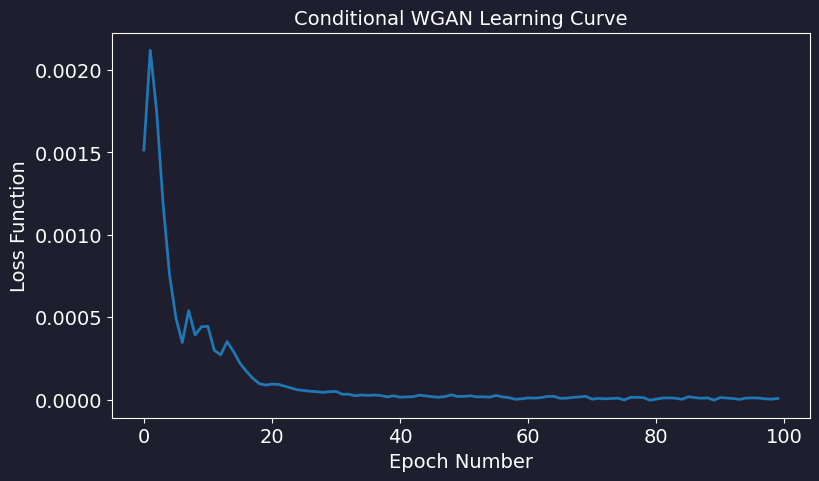

In [70]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
#plt.grid(b=1, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 8 (0.5 балла)

Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`. Перед сравнением результатов сделайте обратное квантильное преобразование с помощью трансформера, который вы обучили в задании 2.

In [71]:
### YOUR CODE IS HERE ######

### THE END OF YOUR CODE ###

In [72]:
X_fake_train = generate(fitter.generator, y_train, latent_dim)
X_fake_train_t = qt.inverse_transform(X_fake_train)
X_train_t = qt.inverse_transform(X_train)

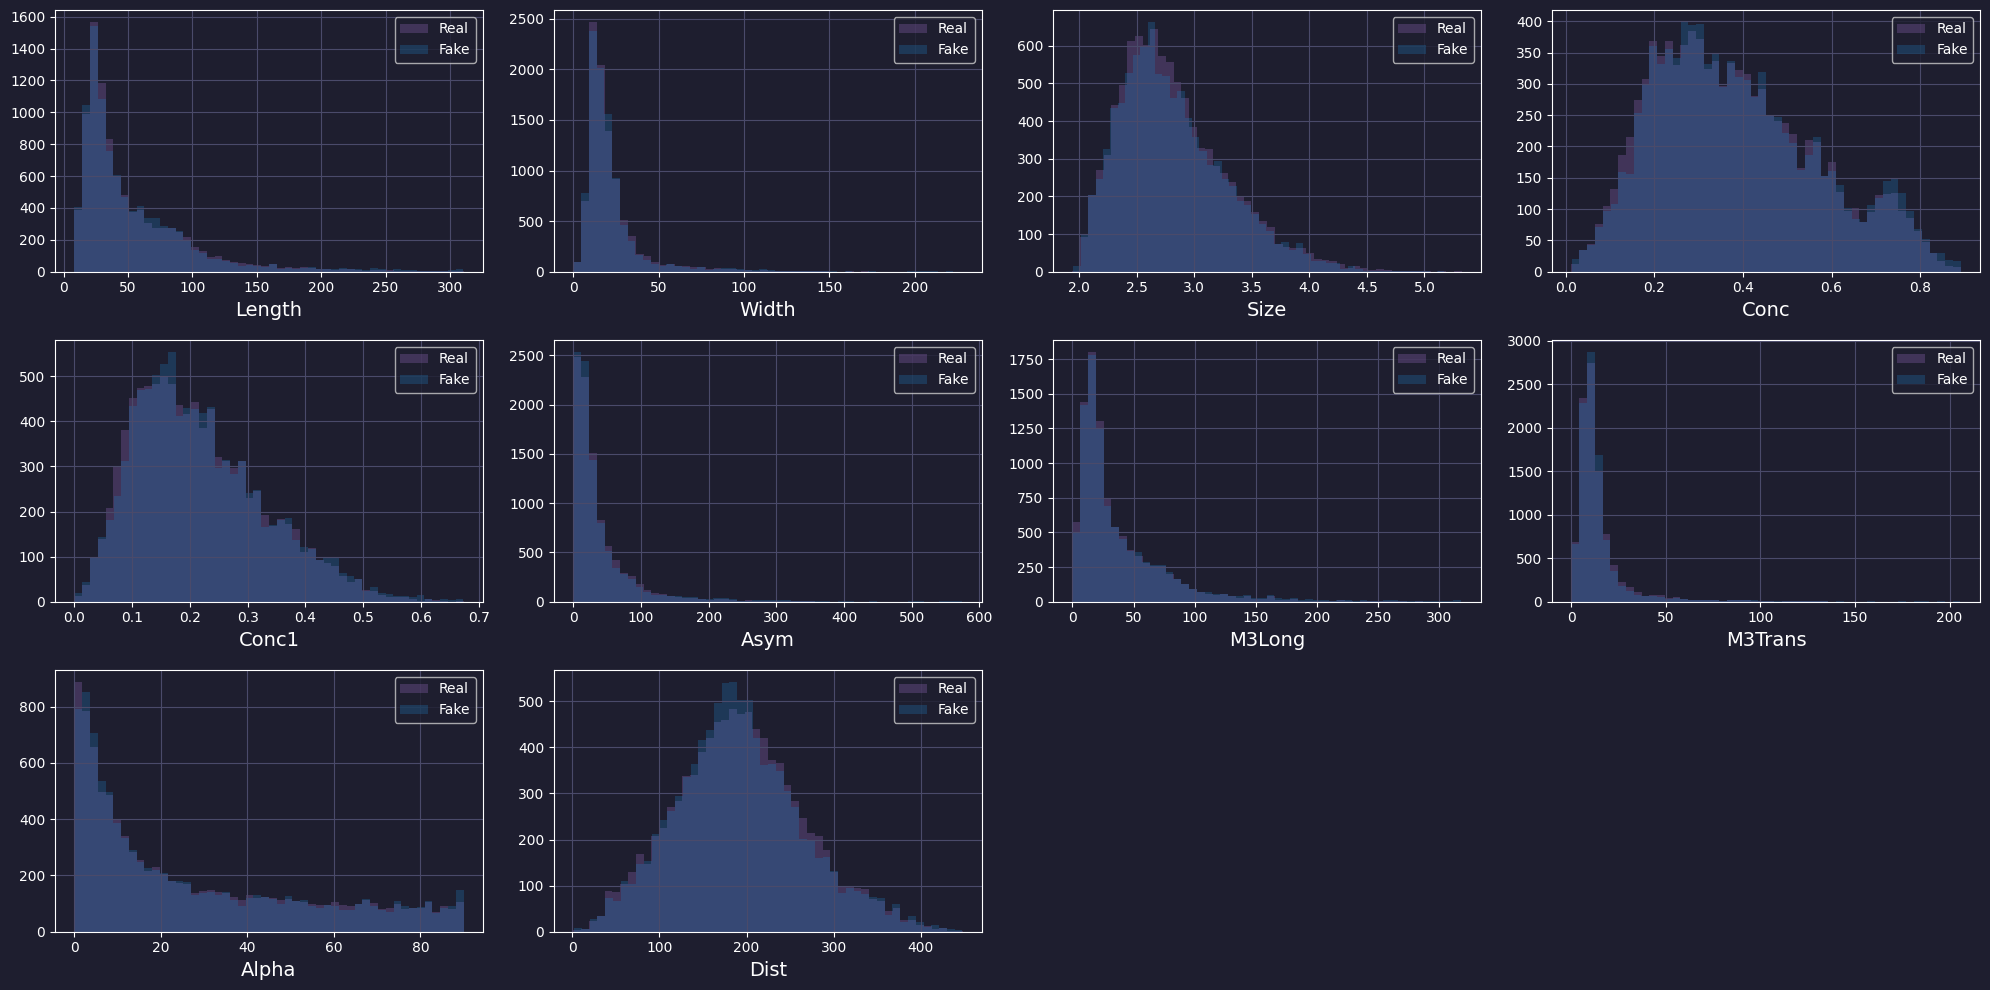

In [73]:
plot_hists(X_train_t, X_fake_train_t, names, label1="Real", label2="Fake", bins=50)

In [74]:
X_fake_test = generate(fitter.generator, y_test, latent_dim)
X_fake_test_t = qt.inverse_transform(X_fake_test)
X_test_t = qt.inverse_transform(X_train)

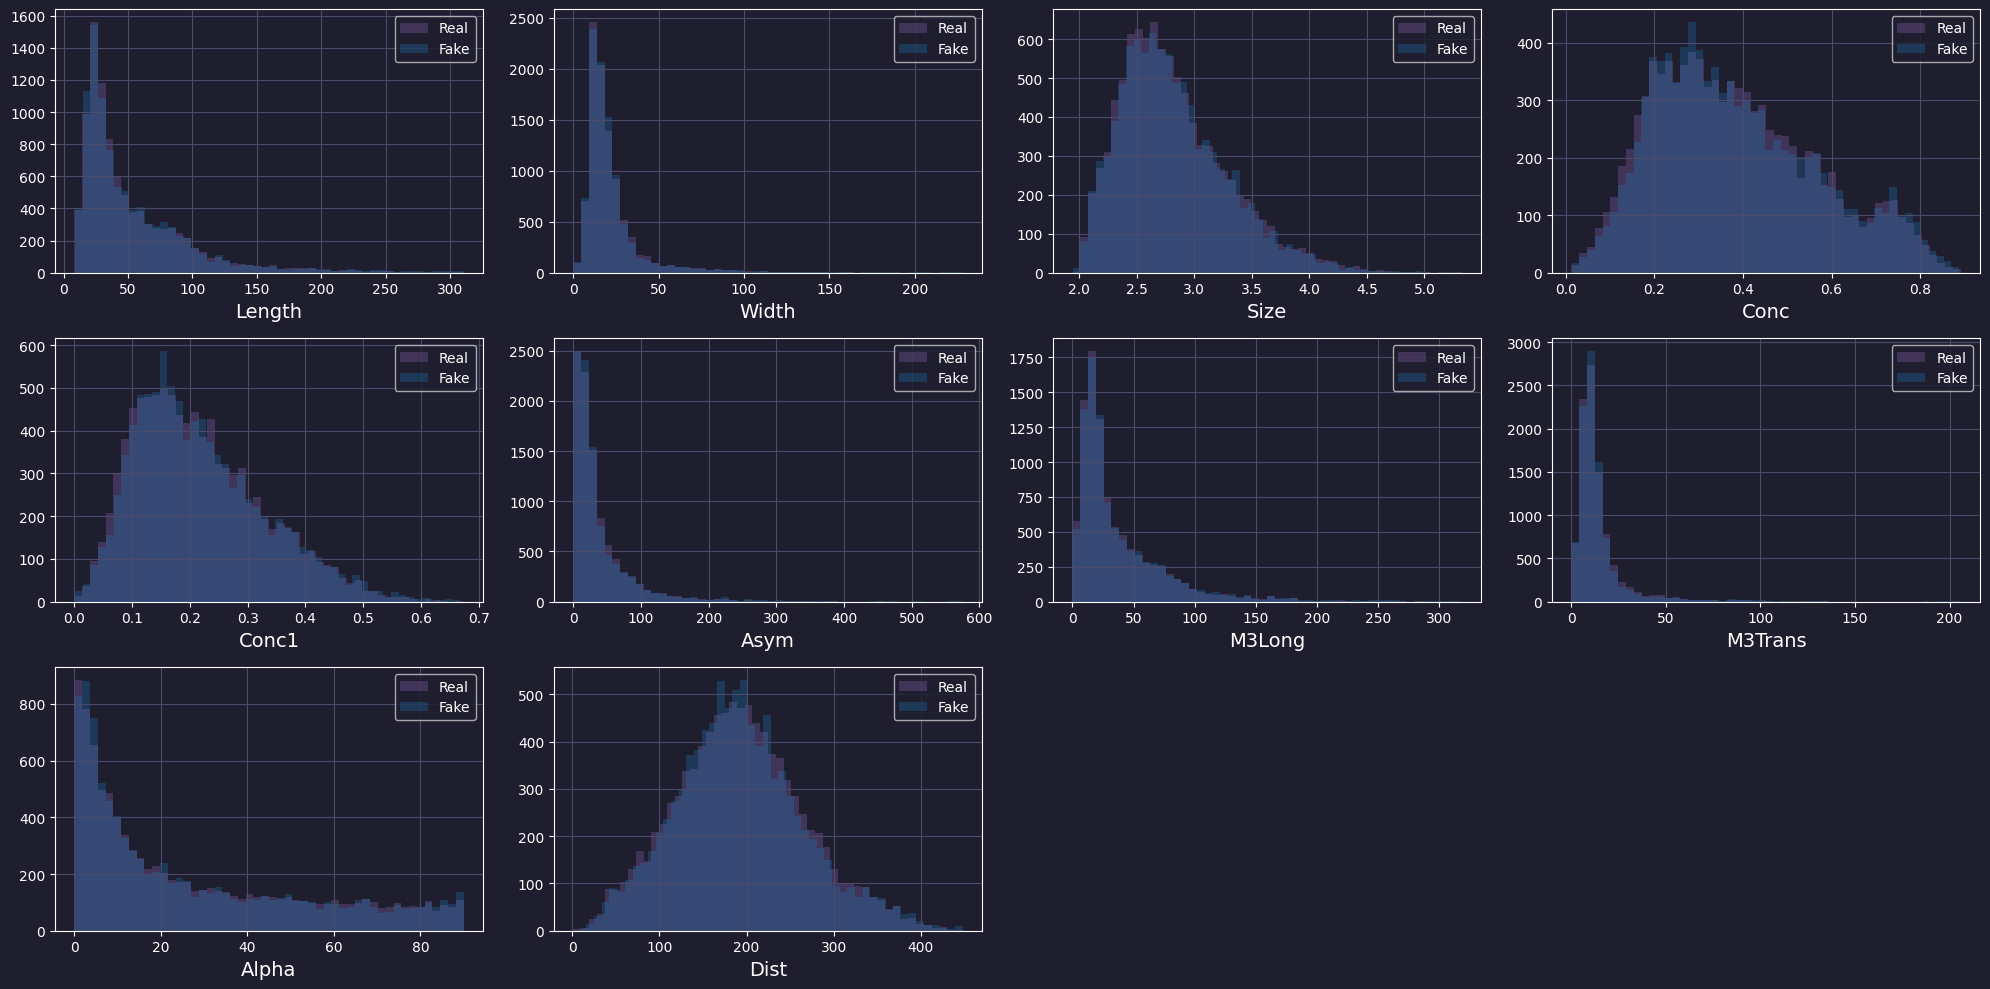

In [75]:
plot_hists(X_test_t, X_fake_test_t, names, label1="Real", label2="Fake", bins=50)

## Ответьте на вопросы:
- Похожи ли фейковые объекты на реальные? Похожи
- Точно ли хорошая идея сравнивать их на глаз? Нет, поскольку это проекции многомерного пространства на ось.


# Измерение качества генерации

<center><img src="img/clf.png" width="600"></center>

Измерим сходство распределений классификатором.

In [76]:
# собираем реальный и фейковые матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [78]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6999586024340972


## Задание 9 (0.5 балла)

Опишите ваш эксперимент. Как вы оцениваете полученные результаты? Как вы думаете, какое значение ROC AUC нас удовлетворяет больше всего? Почему?


Мы учили условно две модели: генератор и дискриминатор. Генератор создавал данные из шума, а дискриминатор учился их отличать от реальных. Полученные результаты скорее удовлитоврительные. Идеальный ROC-AUC = 0.5, поскольку соответсвует случайному классификатору, как я писала ранее, такой вариант наилучший. Наша модель показала значение 0.69 => все еще выходит отличать реальные объекты от фейковых

## Диффузионные модели.

Давайте теперь проведем такой же экперимент с простой диффузионной моделью.

## Задание 10 (0.5 балла)

Воспользуйтесь [DDPMScheduler](https://huggingface.co/docs/diffusers/api/schedulers/ddpm), возьмите 1000 шагов и подумайте, надо ли указать ещё какой-то параметр.

__Подсказка__: Посмотрите на распределения выше и почитайте описание шедулера в документации. Один из параметров - наследие от использования в генерации картинок, а у нас не картинки.

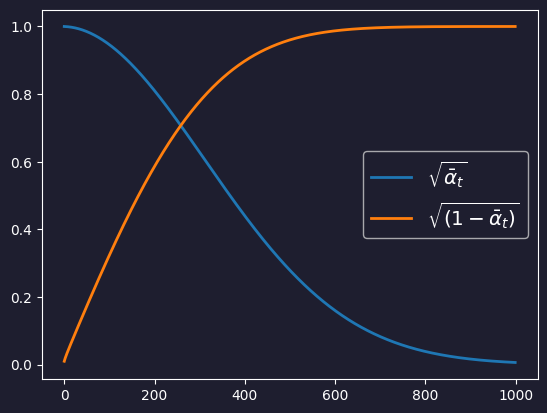

In [79]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
    variance_type="fixed_small",
)
plt.plot(
    noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$"
)
plt.plot(
    (1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5,
    label=r"$\sqrt{(1 - \bar{\alpha}_t)}$",
)
plt.legend(fontsize="x-large")

## Задание 11 (0.5 балла)

Реализуйте нейронную сеть. В качестве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов (Кстати, как вы будете качество измерять?).

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [80]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(DiffusionGenerator, self).__init__()

        self.fc1 = nn.Linear(n_inputs, 100)
        self.bn1 = nn.BatchNorm1d(100)
        self.fc2 = nn.Linear(100, 100)
        self.bn2 = nn.BatchNorm1d(100)
        self.fc3 = nn.Linear(100, n_outputs)

    def forward(self, z, t, y):
        # Склейте z, t и y при помощи torch.cat
        # Подумайте по какому dim это нужно сделать (в качестве подсказки можете посмотреть документацию Linear)
        # А также о том, что t, скорее всего, одно число, а батч у вас будет большой!
        # Либо предусмотрите раздувание t где-то в другом месте
        zty = torch.cat((z, t.unsqueeze(1), y), dim=1)
        out = F.relu(self.bn1(self.fc1(zty)))
        out = F.relu(self.bn2(self.fc2(out)))
        return self.fc3(out)

## Задание 12 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [88]:
def generate_with_diffusion(model, y, latent_dim, sheduler):

    t = torch.linspace(start=0, end=999, steps=y.shape[0]).long()

    cond_tensor = y if isinstance(y, torch.Tensor) else torch.tensor(y).float()

    gaussian_noise = torch.randn(size=(len(y), latent_dim))
    noisy_input = sheduler.add_noise(cond_tensor, gaussian_noise, t)

    with torch.no_grad():
        generated = model(noisy_input.to(cond_tensor.device),
                      cond_tensor.to(cond_tensor.device))

    return generated.detach().cpu().numpy()

## Задание 13 (2 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. В качестве подсказки - опирайтесь на семинар по диффузионным моделям. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [82]:
class DiffusionFitter(object):
    def __init__(
        self,
        model,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.model = generator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic
        self.loss_fn = nn.MSELoss()

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in tqdm(range(self.n_epochs)):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                ### YOUR CODE IS HERE ######

                # Подсказки:
                # Подумайте какой шум вам тут нужен (uniform/normal?)
                # Помните про scheduler? Как вариант, можете генерировать случайный вектор из integer
                # И подавать его в add_noise и модель

                noise = torch.rand_like(real_batch)
                amount = torch.rand(real_batch.size(0)).view(-1, 1).to(DEVICE)

                noised = (real_batch.to(DEVICE) * (1 - amount)
                          + noise.to(DEVICE) * amount)

                with torch.set_grad_enabled(True):
                    self.opt_gen.zero_grad()
                    prediction = self.model(noised.detach(), cond_batch)
                    current_loss = self.loss_fn(prediction, real_batch.to(DEVICE))

                    current_loss.backward()
                    self.opt_gen.step()

                loss_epoch += current_loss.detach().cpu().item()


            loss_epoch = loss_epoch / (i + 1)
                ### THE END OF YOUR CODE ###

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch)

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch)

            # Создайте выборку из 1000 объектов из X_train и 1000 сгенерированных объектов
            # И запустите работу фукнции other_agent_score

            eval_samples = 1000
            ground_truth = X_real[:eval_samples].clone().to(DEVICE)

            batch_size = ground_truth.size(0)
            mixing_ratio = torch.rand(batch_size, device=DEVICE).unsqueeze(1)
            perturbation = torch.randn_like(ground_truth)

            mixed_input = ground_truth * (1 - mixing_ratio) + perturbation * mixing_ratio

            synthetic_output = self.model(
                mixed_input.detach(),
                y_cond[:eval_samples].to(DEVICE)
            )

            other_agent_score(
                X_real=ground_truth.cpu().numpy(),
                y_real=torch.ones(eval_samples),
                X_fake=synthetic_output.detach().cpu().numpy(),
                y_fake=torch.zeros(eval_samples)
            )

        # Turn off training
        self.model.train(False)

Обучим модель на данных, указав количество входов.

У вас есть скрытое пространство и его размер, есть таймстепы и есть условие. Как легко догадаться, размер входа будет больше, чем просто размер скрытого пространства.

In [83]:
%%time
latent_dim = 10
model = DiffusionGenerator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
diffusionFitter.fit(X_train, y_train)

  1%|          | 1/100 [00:01<01:55,  1.17s/it]

Linear regression score: 0.534
Boosting score: 0.712


  2%|▏         | 2/100 [00:02<01:54,  1.17s/it]

Linear regression score: 0.476
Boosting score: 0.668


  3%|▎         | 3/100 [00:03<01:53,  1.17s/it]

...

Linear regression score: 0.492
Boosting score: 0.508


 99%|█████████▉| 99/100 [01:59<00:01,  1.20s/it]

Linear regression score: 0.498
Boosting score: 0.558


100%|██████████| 100/100 [02:01<00:00,  1.21s/it]

Linear regression score: 0.484
Boosting score: 0.532
CPU times: user 2min, sys: 10.9 s, total: 2min 11s
Wall time: 2min 1s


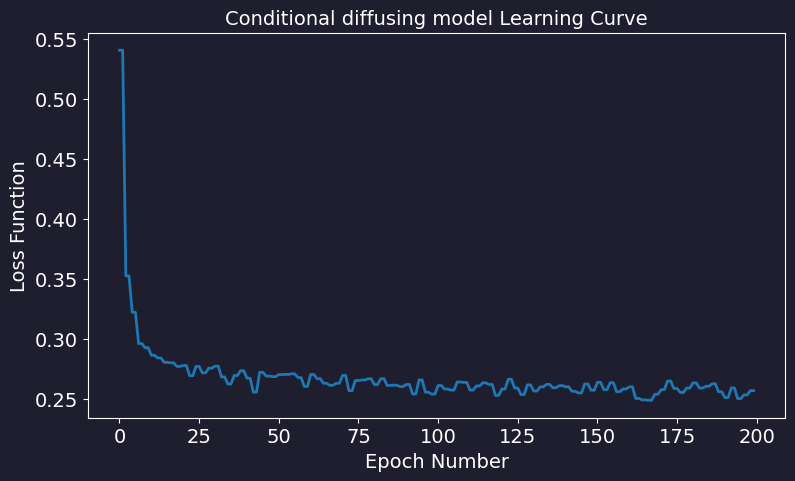

In [84]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
#plt.grid(b=1, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 14 (0.5 балла)
По аналогии с прошлым экспериментом с GAN моделью сгенерируйте выборку фейковых объектов равную размеру тестовой выборки и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрики ROC-AUC и accuracy score. Какие получились результаты? Как вы их оцениваете? А в сравнении с GAN моделью?

In [89]:
X_fake_train = generate_with_diffusion(diffusionFitter.model, y_train, latent_dim, noise_scheduler)
X_fake_train_t = qt.inverse_transform(X_fake_train)
X_train_t = qt.inverse_transform(X_train)

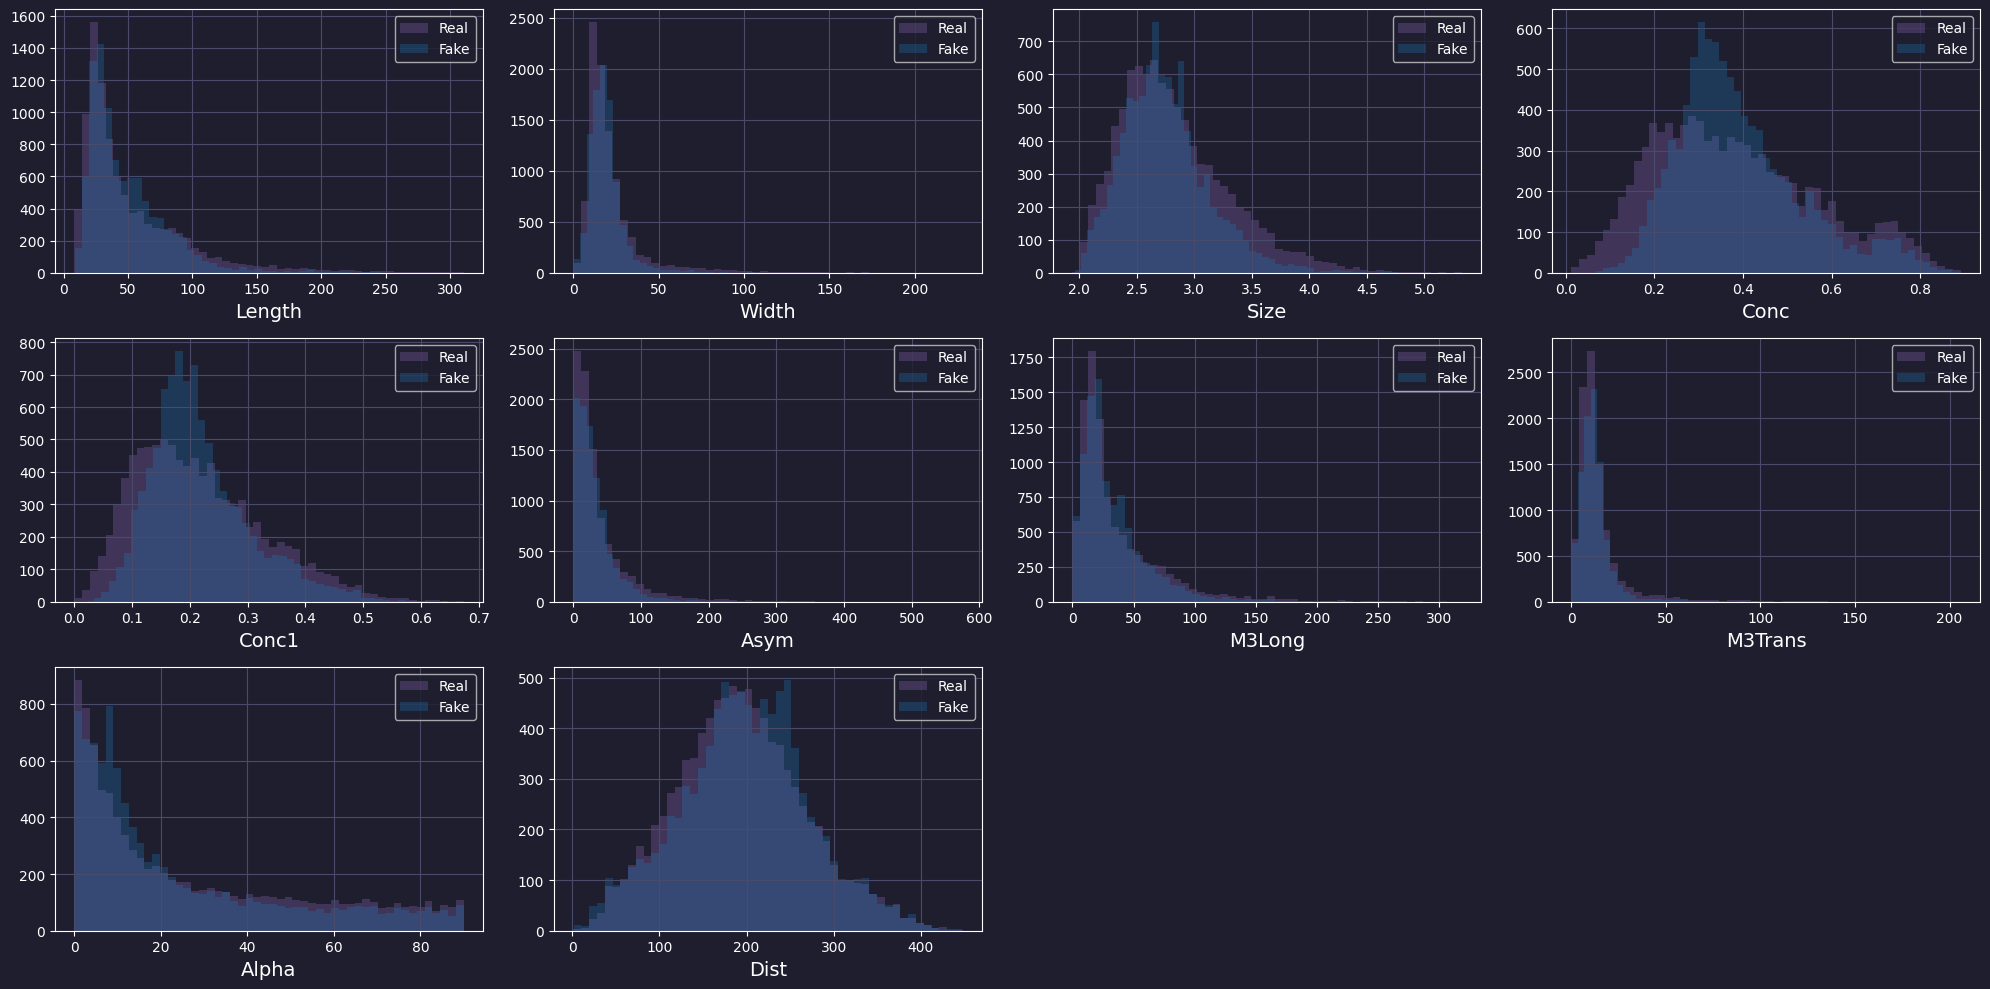

In [90]:
plot_hists(X_train_t, X_fake_train_t, names, label1="Real", label2="Fake", bins=50)

In [91]:
X_fake_test = generate_with_diffusion(diffusionFitter.model, y_test, latent_dim, noise_scheduler)
X_fake_test_t = qt.inverse_transform(X_fake_test)
X_test_t = qt.inverse_transform(X_test)

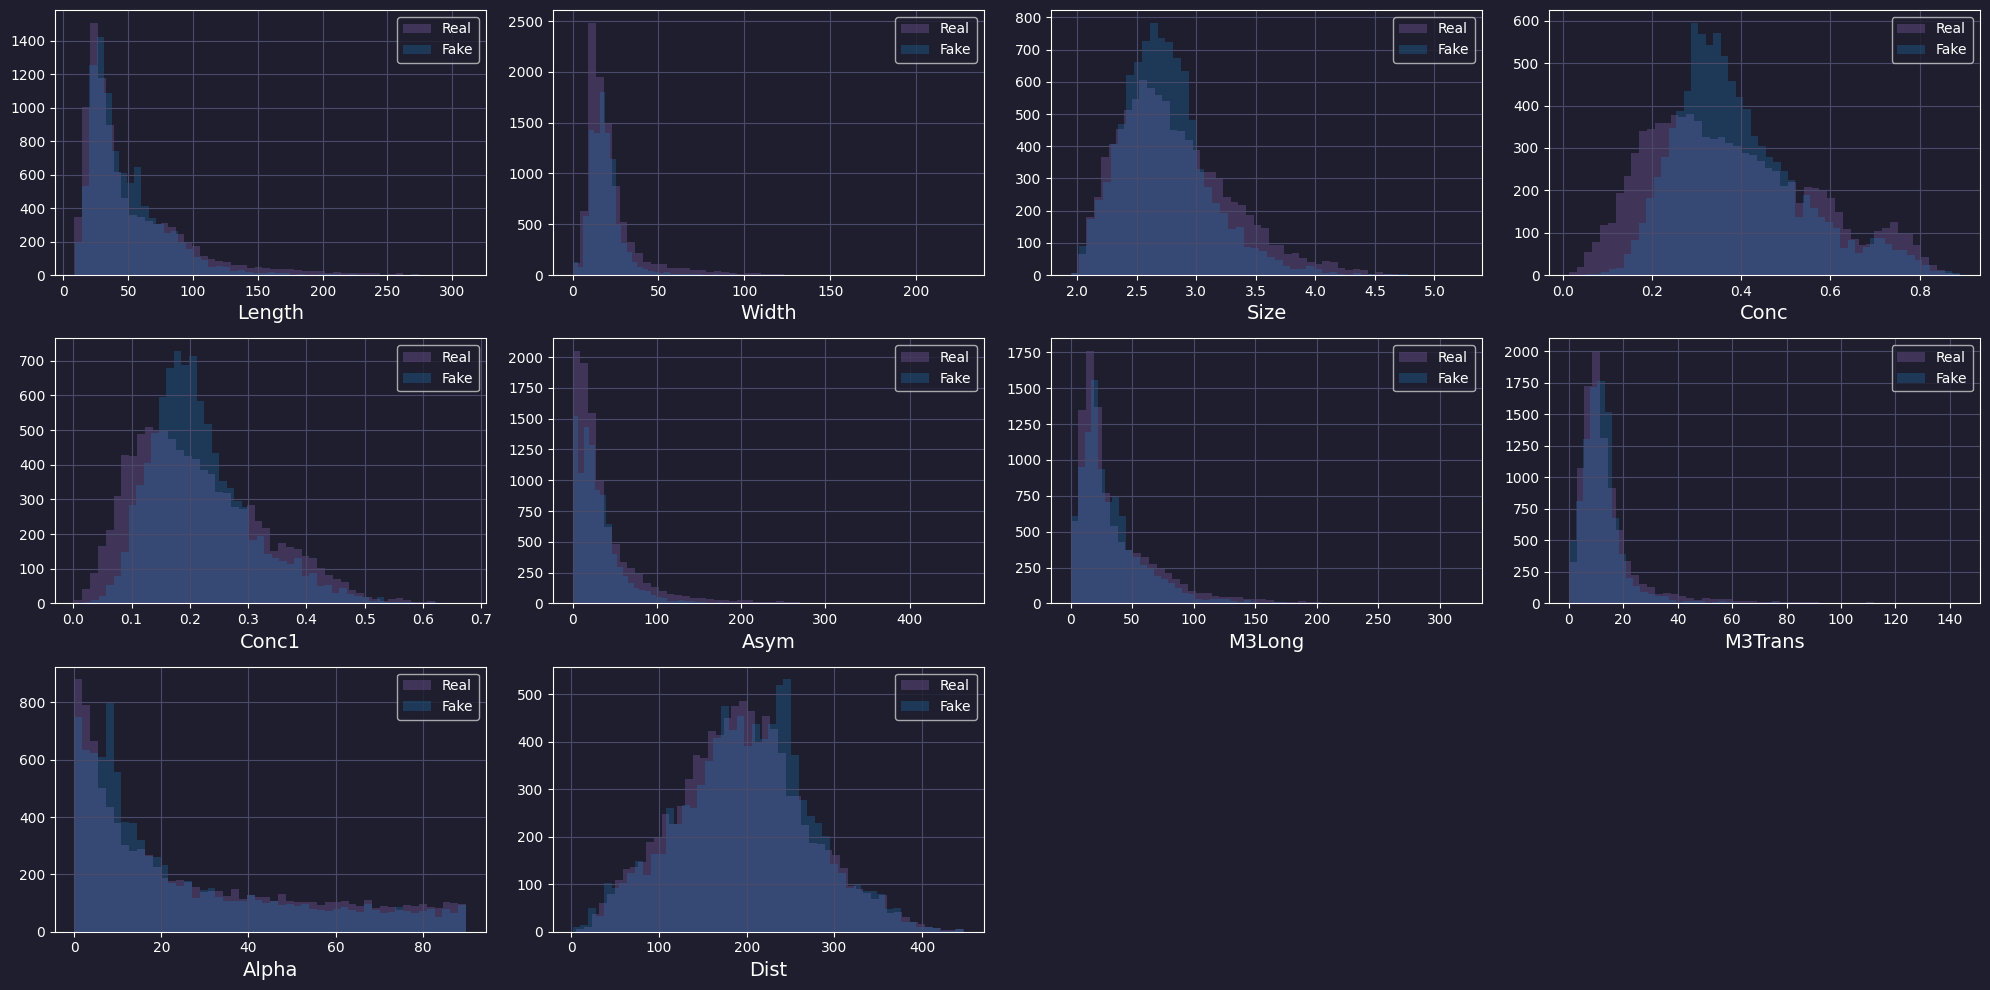

In [92]:
plot_hists(X_test_t, X_fake_test_t, names, label1="Real", label2="Fake", bins=50)

In [93]:
# собираем реальный и фейковые матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

from sklearn.ensemble import GradientBoostingClassifier

# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.8781003116980189


Ну что сказать, качество у диффузии вышло похуже (сильно) чем у ганов, ничего не могу с этим сделать. Классификаторы хорошо отличают реальные объекты от фейковых (рок аук 0.87) - для нас это плохо, диффузии справились хуже ганов. THE END.

# Бонус (2 балла)

Кроме Diffusion и GAN вы изучили еще VAE и NF. В качестве бонуса релизуйте VAE, обучите, и в конце сравните качество теми же методами, что и в основной части ДЗ.

Разбалловка бонуса такая:
- Реализовать VAE - 1 балл
- Обучить VAE - 0.5 балла
- Провести сравнение с GAN и Diffusion аналогично 14 заданию основной части - 0.5 балла

Ниже приведены шаблоны. Они не особо щедры на комментарии, но поскольку задача бонусная, ожидаем, что вы в них разберетесь. Если они вам не нравятся - можете переписать как хотите.

Если же VAE вам кажется слишком скучным, то мы засчитаем реализацию NF, но шаблонов не предоставим. Бонус в таком случае тоже ограничен сверху 2 баллами и разбалловка не изменится.

## Отзыв

Поздравляю! Вы дошли до конца. Оставьте ваш отзыв ячейкой ниже или отправьте его в канал курса, нам будет очень интересно!

In [103]:
print('Фку нщг ыукшщгы. Нуы ш фь!')

Фку нщг ыукшщгы. Нуы ш фь!
